# LiDAR analyses — GEDI sample points (South Fork Eel / Angelo)

**What this is.** A worked example of an *offline* analysis whose results land in the atlas as
ordinary deltas. It takes a small field-sample package — three points at Angelo Reserve, one per
MTBS burn-severity class — and attaches canopy-structure metrics to the `mtbs_sample` layer.

**The inputs** (`s3://scs-internal/SouthForkEel_field_trip_errata/sample2/`):

| File | What it is |
|---|---|
| `AngeloPointSamples.gpkg` | The three sample points (EPSG:6339, UTM 10N) with `MTBS_severity`. |
| `{low,medium,unburned}{year}.las` | Airborne LiDAR (ALS) clips, ~24 m square, around each point, for 2004/2009/2014/2018. |
| `{Low,Med,Unb}Sev.csv` | **Simulated GEDI** metrics, one row per year. A GEDI simulator (`gediRat`/`gediMetric`) turns each ALS clip into the waveform the GEDI satellite would record over a ~25 m footprint, then extracts the standard metrics (relative heights, cover, foliage-height diversity, LAI by height band). |
| `*.h5` | The simulated waveforms themselves (GEDI L1B layout). Not used here. |

**What this notebook does.**
1. Loads the sample points and the simulated GEDI metrics.
2. Drops known-bad timepoints (see *Exclusions*).
3. **Recovers the ALS reference metrics** the simulator left empty (`true ground`, `ALS cover`,
   `rhReal *` are all nodata in the CSVs), straight from the ground-classified point clouds.
4. Compares GEDI-simulated vs ALS-measured values — a sanity check on the simulation.
5. Builds two deltas against the live `mtbs_sample` layer, matched by `atlas_id`:
   a **`reshape`** delta (moves each point to its surveyed position) and a **`match`** delta
   (attaches the metrics as properties).

**Re-running with updated files** — replace the files on S3, empty `EXCLUDE`, and re-run. Both
deltas are idempotent: `reshape` replaces geometry, `match` overwrites properties by key.
Nothing is posted unless `APPLY_DELTAS=1` is set in the environment.

In [1]:
import os, io, json, sqlite3, struct, datetime
from pathlib import Path
import numpy as np
import requests
import laspy                      # pip install laspy   (pure Python; not on the box by default)
from pyproj import Transformer
import matplotlib.pyplot as plt

ATLAS = "south_fork_eel"
LAYER = "mtbs_sample"
API = "https://fireatlas.org:9000"
LAYER_URL = f"https://fireatlas.org/{ATLAS}/staging/layers/{LAYER}/{LAYER}.geojson"

SAMPLE_S3 = "s3://scs-internal/SouthForkEel_field_trip_errata/sample2/"
SAMPLE_HTTP = "https://scs-internal.s3.us-west-1.amazonaws.com/SouthForkEel_field_trip_errata/sample2/"
CACHE = Path(os.environ.get("ATLAS_NB_CACHE", Path.home() / ".cache" / "atlas_notebooks")) / "lidar_sample2"
CACHE.mkdir(parents=True, exist_ok=True)   # outside the outlet dir, so publish never snapshots it

APPLY = os.environ.get("APPLY_DELTAS") == "1"   # or set APPLY = True here to post the deltas

## Exclusions

Found by inspecting the package (2026-10-01):

* **2004 and 2014 are the same point cloud.** At all three sites the `*2004.las` and `*2014.las`
  clips hold identical points (same count, same extents) and give identical GEDI metrics to every
  digit. Nothing says which year is genuine, so **both are dropped**.
* **Unburned 2009 is kept.** Its CSV row says `med2009.h5`, but its values match the unburned clip
  (ground ≈ 415 m vs medium's ≈ 458 m) and the `med2009.h5` file's own geolocation is the unburned
  point — the unburned run overwrote medium's waveform file. The medium-2009 *metrics* survive in
  `MedSev.csv`; only its `.h5` is lost.
* The 2009 clips contain **first returns only**; 2004/2014/2018 have multiple returns. All-return
  ALS metrics (percentiles, ladder fraction) are therefore not strictly comparable across 2009↔2018.
  Cover uses first returns only, which *is* comparable.

In [2]:
SITES = {          # site key -> (CSV file, LAS prefix, GeoPackage MTBS_severity, live-layer name)
    "low":      ("LowSev.csv", "low",      "LOW",      "low"),
    "medium":   ("MedSev.csv", "medium",   "Medium",   "Med"),
    "unburned": ("UnbSev.csv", "unburned", "Unburned", "unburned"),
}
EXCLUDE = {"*": [2004, 2014]}        # site key or "*" -> years to drop

def excluded(site, year):
    return year in EXCLUDE.get("*", []) or year in EXCLUDE.get(site, [])

def fetch(name):
    p = CACHE / name
    if not p.exists():
        r = requests.get(SAMPLE_HTTP + name, timeout=60); r.raise_for_status()
        p.write_bytes(r.content)
    return p

files = ["AngeloPointSamples.gpkg"] + [s[0] for s in SITES.values()] + \
        [f"{s[1]}{y}.las" for s in SITES.values() for y in (2004, 2009, 2014, 2018)]
for f in files:
    fetch(f)
print(f"{len(files)} files in {CACHE}")

16 files in ~/.cache/atlas_notebooks/lidar_sample2


## Sample points

The GeoPackage is the surveyed position of each sample (EPSG:6339 = NAD83(2011) / UTM 10N; the LAS
clips are EPSG:26910, NAD83 / UTM 10N — the same grid to well under a metre). GeoPackage geometry
is a small header followed by WKB; for three points it's simpler to unpack it than pull in GDAL.

In [3]:
def gpkg_points(path, table):
    rows = sqlite3.connect(path).execute(f"select MTBS_severity, geometry from {table}").fetchall()
    out = {}
    for sev, blob in rows:
        flags = blob[3]
        env_len = {0: 0, 1: 32, 2: 48, 3: 48, 4: 64}[(flags >> 1) & 7]
        wkb = blob[8 + env_len:]
        x, y = struct.unpack("<dd", wkb[5:21])
        out[sev] = (x, y)
    return out

pts = gpkg_points(CACHE / "AngeloPointSamples.gpkg", "AngeloPointSamples")
to_ll = Transformer.from_crs("EPSG:6339", "EPSG:4326", always_xy=True)
sites = {}
for key, (_, _, sev, name) in SITES.items():
    e, n = pts[sev]
    lon, lat = to_ll.transform(e, n)
    sites[key] = dict(easting=e, northing=n, lon=round(lon, 6), lat=round(lat, 6), severity=sev, name=name)
    print(f"{key:9s} {sev:9s} E {e:.1f} N {n:.1f} -> {lat:.6f}, {lon:.6f}")

low       LOW       E 446110.4 N 4400285.2 -> 39.750773, -123.629040
medium    Medium    E 445994.5 N 4399918.1 -> 39.747458, -123.630363
unburned  Unburned  E 445716.2 N 4399813.9 -> 39.746501, -123.633602


## Simulated GEDI metrics

Each CSV has ~150 columns. We keep the ones with a clear reading:

| Column(s) | Atlas property | Meaning |
|---|---|---|
| `rhGauss 25/50/75/95/100` | `gedi_rh{n}` | Height (m above the waveform's ground) below which *n*% of the returned energy lies. RH95 ≈ canopy top; RH50 ≈ where the bulk of the vegetation is. |
| `cover` | `gedi_cover` | Canopy cover fraction seen by the waveform. |
| `FHD` | `gedi_fhd` | Foliage height diversity — how evenly vegetation spreads through the vertical profile. Higher = more layered. |
| `gHeight` | `gedi_ground_elev` | Ground elevation (m) estimated from the waveform. |
| `gLAI0t10 … gLAI30t40` | `gedi_lai_{0_10…30_40}` | Leaf area index in 10 m height bands, from the waveform with the Gaussian ground (consistent with `rhGauss`). Low-band LAI is the ladder-fuel signal. |

`rhGauss` uses a Gaussian-fitted ground, the closest analogue to the GEDI L2A product; the CSV
also has `rhMax`/`rhInfl` variants from other ground-finding methods.

The CSV has five LAI variants: `tLAI` is "true" LAI from the point cloud — part of the empty
reference group, `-1` everywhere — and `gLAI`/`hgLAI`/`hiLAI`/`hmLAI` differ only in how the
waveform's ground was found.

**Open question:** the 30–40 m LAI band is 0 in every variant at every site, although the unburned
canopy reaches ~60 m. The simulator was probably configured to profile only up to 30–40 m, in which
case 20–30 m may really mean "above 20 m". Treat the upper bands with suspicion until the producer
confirms the height range.

In [4]:
import csv, re

GEDI_COLS = {
    "gedi_rh25": "rhGauss 25", "gedi_rh50": "rhGauss 50", "gedi_rh75": "rhGauss 75",
    "gedi_rh95": "rhGauss 95", "gedi_rh100": "rhGauss 100",
    "gedi_cover": "cover", "gedi_fhd": "FHD", "gedi_ground_elev": "gHeight",
    "gedi_lai_0_10": "gLAI0t10", "gedi_lai_10_20": "gLAI10t20",
    "gedi_lai_20_30": "gLAI20t30", "gedi_lai_30_40": "gLAI30t40",
}

gedi = {}   # (site, year) -> {prop: value}
for key, (csv_name, *_ ) in SITES.items():
    for row in csv.DictReader(open(CACHE / csv_name)):
        stem = row["filename"].split("\\")[-1]          # e.g. 'low2009.h5'
        year = int(re.search(r"(\d{4})", stem).group(1))
        if excluded(key, year):
            continue
        gedi[(key, year)] = {p: round(float(row[c]), 3) for p, c in GEDI_COLS.items()}

for (k, y), m in sorted(gedi.items()):
    print(f"{k:9s} {y}  rh95 {m['gedi_rh95']:6.2f}  rh50 {m['gedi_rh50']:6.2f}  cover {m['gedi_cover']:.3f}  fhd {m['gedi_fhd']:.2f}")

low       2009  rh95  50.89  rh50  27.94  cover 0.936  fhd 5.89
low       2018  rh95  52.53  rh50  16.23  cover 0.979  fhd 5.66
medium    2009  rh95  26.82  rh50  11.97  cover 0.805  fhd 5.40
medium    2018  rh95  28.10  rh50   9.65  cover 0.917  fhd 5.42
unburned  2009  rh95  57.66  rh50  37.86  cover 0.879  fhd 5.74
unburned  2018  rh95  64.03  rh50  45.73  cover 0.998  fhd 5.72


## ALS reference metrics, recovered from the point clouds

The simulator's reference columns are empty, so we compute the equivalents directly:

1. Keep returns within **12 m** of the sample point (≈ a GEDI footprint; the clips are ~24 m boxes).
2. Fit a **ground plane** to the ground-classified returns (class 2) by least squares. Its value
   at the sample point is the ground elevation; its gradient is the slope. A plane is adequate
   over 24 m; a TIN or grid DTM would matter for larger areas.
3. Height above ground = return elevation − plane. Classes 7/18 (noise) are dropped.

| Property | Meaning |
|---|---|
| `als_ground_elev` | Ground elevation at the sample point (m). Compare with `gedi_ground_elev`. |
| `als_slope_deg` | Terrain slope across the footprint. |
| `als_p50`, `als_p95`, `als_max` | Percentiles of return height above ground (all returns). Compare with `gedi_rh50/95/100`. |
| `als_cover` | Share of **first** returns above 2 m — the standard ALS canopy-cover estimate. |
| `als_ladder` | Share of returns below 4 m that fall between 1 and 4 m — a simple ladder-fuel density. |
| `als_returns` | Returns used. |

In [5]:
RADIUS = 12.0
NOISE = {7, 18}

def als_metrics(las_path, e0, n0):
    las = laspy.read(las_path)
    x, y, z = np.asarray(las.x), np.asarray(las.y), np.asarray(las.z)
    cls = np.asarray(las.classification)
    first = np.asarray(las.return_number) == 1
    keep = (np.hypot(x - e0, y - n0) <= RADIUS) & ~np.isin(cls, list(NOISE))
    g = keep & (cls == 2)
    A = np.c_[x[g] - e0, y[g] - n0, np.ones(g.sum())]
    (a, b, c), *_ = np.linalg.lstsq(A, z[g], rcond=None)        # z = a*dx + b*dy + c
    h = z - (a * (x - e0) + b * (y - n0) + c)
    hk, fk = h[keep], h[keep & first]
    low = hk[hk < 4]
    return {
        "als_ground_elev": round(float(c), 2),
        "als_slope_deg": round(float(np.degrees(np.arctan(np.hypot(a, b)))), 1),
        "als_p50": round(float(np.percentile(hk, 50)), 2),
        "als_p95": round(float(np.percentile(hk, 95)), 2),
        "als_max": round(float(hk.max()), 2),
        "als_cover": round(float((fk > 2).mean()), 3),
        "als_ladder": round(float(((low >= 1) & (low < 4)).mean()), 3),
        "als_returns": int(keep.sum()),
    }, hk

als, heights = {}, {}
for key, (_, las_prefix, *_ ) in SITES.items():
    s = sites[key]
    for year in (2004, 2009, 2014, 2018):
        if excluded(key, year):
            continue
        als[(key, year)], heights[(key, year)] = als_metrics(
            CACHE / f"{las_prefix}{year}.las", s["easting"], s["northing"])

for (k, y), m in sorted(als.items()):
    print(f"{k:9s} {y}  " + "  ".join(f"{p.replace('als_','')} {v}" for p, v in m.items()))

low       2009  ground_elev 401.28  slope_deg 8.6  p50 30.03  p95 50.4  max 56.52  cover 0.884  ladder 0.361  returns 7211
low       2018  ground_elev 401.68  slope_deg 9.1  p50 15.37  p95 50.92  max 57.62  cover 0.732  ladder 0.254  returns 6392
medium    2009  ground_elev 457.87  slope_deg 32.2  p50 13.02  p95 24.74  max 31.39  cover 0.832  ladder 0.433  returns 11458
medium    2018  ground_elev 458.85  slope_deg 32.9  p50 4.8  p95 24.61  max 31.24  cover 0.68  ladder 0.36  returns 5836
unburned  2009  ground_elev 418.79  slope_deg 25.8  p50 39.59  p95 60.09  max 68.01  cover 0.892  ladder 0.039  returns 8428
unburned  2018  ground_elev 418.94  slope_deg 25.8  p50 43.47  p95 61.84  max 69.92  cover 0.99  ladder 0.06  returns 8058


## Does the simulation agree with the point cloud?

GEDI's relative heights are energy-weighted and measured from the waveform's own ground, so they
should track — not equal — the ALS return percentiles. Large gaps would point at a ground-finding
problem in the simulation or a mismatch between clip and footprint.

In [6]:
print(f"{'site':9s} {'year':4s} | {'ground gedi-als':>15s} | {'rh95 / als p95':>15s} | {'rh100 / als max':>15s} | {'cover gedi / als':>16s}")
for k_y in sorted(gedi):
    g, a = gedi[k_y], als[k_y]
    print(f"{k_y[0]:9s} {k_y[1]} | {g['gedi_ground_elev'] - a['als_ground_elev']:+15.2f} | "
          f"{g['gedi_rh95']:6.1f} / {a['als_p95']:6.1f} | {g['gedi_rh100']:6.1f} / {a['als_max']:6.1f} | "
          f"{g['gedi_cover']:7.3f} / {a['als_cover']:6.3f}")

site      year | ground gedi-als |  rh95 / als p95 | rh100 / als max | cover gedi / als
low       2009 |           -0.04 |   50.9 /   50.4 |   60.0 /   56.5 |   0.936 /  0.884
low       2018 |           -1.98 |   52.5 /   50.9 |   62.9 /   57.6 |   0.979 /  0.732
medium    2009 |           +0.22 |   26.8 /   24.7 |   35.4 /   31.4 |   0.805 /  0.832
medium    2018 |           -3.50 |   28.1 /   24.6 |   38.9 /   31.2 |   0.917 /  0.680
unburned  2009 |           +0.15 |   57.7 /   60.1 |   75.4 /   68.0 |   0.879 /  0.892
unburned  2018 |           -4.58 |   64.0 /   61.8 |   81.6 /   69.9 |   0.998 /  0.990


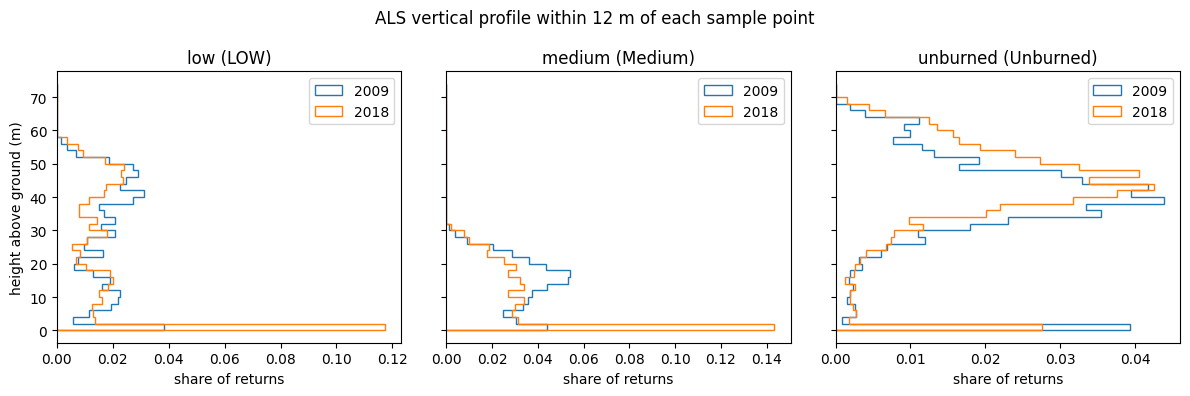

In [7]:
fig, axes = plt.subplots(1, len(SITES), figsize=(12, 4), sharey=True)
bins = np.arange(0, 75, 2)
for ax, key in zip(axes, SITES):
    for year in sorted(y for (k, y) in heights if k == key):
        ax.hist(heights[(key, year)], bins=bins, orientation="horizontal",
                histtype="step", density=True, label=str(year))
    ax.set_title(f"{key} ({sites[key]['severity']})")
    ax.set_xlabel("share of returns")
    ax.legend()
axes[0].set_ylabel("height above ground (m)")
fig.suptitle("ALS vertical profile within 12 m of each sample point")
fig.tight_layout()

### Reading the results (as of the 2026-10-01 package)

* **2009 agrees closely.** Waveform ground is within 0.25 m of the ALS ground plane at all three
  sites, and RH95 is within ~2 m of the ALS 95th percentile.
* **2018 ground is 2–4.6 m low in the simulation.** The 2018 clips are denser, multi-return
  acquisitions, and the simulator's Gaussian ground lands below the classified ground. That inflates
  every 2018 GEDI relative height by roughly the same amount — part of the apparent 2009→2018
  "growth" in `gedi_rh95`/`gedi_rh100` is this artefact. **For change over time, prefer the
  `als_*` properties.**
* **Severity shows clearly in structure.** Unburned: tall (p95 ≈ 60 m), almost no returns in the
  1–4 m band (`als_ladder` ≈ 0.04–0.06). Low and medium severity: much more low vegetation
  (`als_ladder` 0.25–0.43) — post-fire regrowth and the ladder-fuel signal. Medium sits on a 32°
  slope, worth remembering when comparing.
* `als_cover` falls from 2009 to 2018 at the burned sites, but 2009 is first-return-only and 2018
  multi-return, so treat that as a sensor difference until a like-for-like pair exists.

## Choose what goes to the atlas

Everything above stays here in the notebook. The atlas gets a small, practitioner-readable subset —
what someone asking *"how did the forest change between these years?"* needs, all from the simulated
GEDI metrics so it reads as one product:

| Property | From | Meaning |
|---|---|---|
| `mtbs_severity` | GeoPackage | Burn-severity class |
| `canopy_height_m_{year}` | `gedi_rh95` | Canopy height (m) |
| `canopy_cover_pct_{year}` | `gedi_cover` × 100 | Canopy cover (%) |
| `foliage_height_diversity_{year}` | `gedi_fhd` | Vertical layering of the canopy |
| `understory_lai_{year}` | `gedi_lai_0_10` | Leaf area 0–10 m: low vegetation / ladder fuel |

Caveat for readers: these are **simulated** GEDI metrics (GEDI launched in Dec 2018), and the 2018
heights likely read 2–4 m high because of the ground offset found above.

In [8]:
ATLAS_PROPS = {   # atlas property stem -> (notebook metric, scale, decimals)
    "canopy_height_m":          ("gedi_rh95",     1,   1),
    "canopy_cover_pct":         ("gedi_cover",    100, 0),
    "foliage_height_diversity": ("gedi_fhd",      1,   2),
    "understory_lai":           ("gedi_lai_0_10", 1,   3),
}

def atlas_props(key):
    props = {"mtbs_severity": sites[key]["severity"]}
    for year in sorted(y for (k, y) in gedi if k == key):
        for stem, (metric, scale, nd) in ATLAS_PROPS.items():
            v = round(gedi[(key, year)][metric] * scale, nd)
            props[f"{stem}_{year}"] = int(v) if nd == 0 else v
    return props

for key in SITES:
    print(key, atlas_props(key))

low {'mtbs_severity': 'LOW', 'canopy_height_m_2009': 50.9, 'canopy_cover_pct_2009': 94, 'foliage_height_diversity_2009': 5.89, 'understory_lai_2009': 0.042, 'canopy_height_m_2018': 52.5, 'canopy_cover_pct_2018': 98, 'foliage_height_diversity_2018': 5.66, 'understory_lai_2018': 0.043}
medium {'mtbs_severity': 'Medium', 'canopy_height_m_2009': 26.8, 'canopy_cover_pct_2009': 80, 'foliage_height_diversity_2009': 5.4, 'understory_lai_2009': 0.139, 'canopy_height_m_2018': 28.1, 'canopy_cover_pct_2018': 92, 'foliage_height_diversity_2018': 5.42, 'understory_lai_2018': 0.13}
unburned {'mtbs_severity': 'Unburned', 'canopy_height_m_2009': 57.7, 'canopy_cover_pct_2009': 88, 'foliage_height_diversity_2009': 5.74, 'understory_lai_2009': 0.005, 'canopy_height_m_2018': 64.0, 'canopy_cover_pct_2018': 100, 'foliage_height_diversity_2018': 5.72, 'understory_lai_2018': 0.005}


## Build the deltas

The live layer is read to map each site to its `atlas_id` by the hand-entered `name`
(`low` / `Med` / `unburned`).

In [9]:
live = requests.get(LAYER_URL, timeout=30).json()
ids = {f["properties"]["name"]: f["properties"]["atlas_id"] for f in live["features"]}

reshape_feats, match_feats = [], []
for key, s in sites.items():
    aid = ids[s["name"]]
    point = {"type": "Point", "coordinates": [s["lon"], s["lat"]]}
    reshape_feats.append({"type": "Feature", "geometry": point, "properties": {"atlas_id": aid}})
    match_feats.append({"type": "Feature", "geometry": point, "properties": {"atlas_id": aid, **atlas_props(key)}})

reshape_delta = {"type": "FeatureCollection", "layer": LAYER, "action": "reshape", "features": reshape_feats}
match_delta = {"type": "FeatureCollection", "layer": LAYER, "action": "match", "features": match_feats}

prop_names = []
for f in match_feats:
    prop_names += [p for p in f["properties"] if p not in prop_names and p != "atlas_id"]
print(len(prop_names), "properties:", prop_names)

9 properties: ['mtbs_severity', 'canopy_height_m_2009', 'canopy_cover_pct_2009', 'foliage_height_diversity_2009', 'understory_lai_2009', 'canopy_height_m_2018', 'canopy_cover_pct_2018', 'foliage_height_diversity_2018', 'understory_lai_2018']


The `editable_columns` list for `mtbs_sample` in the atlas config must name every property for
the webmap popup to show it. This prints the block that belongs in `south_fork_eel.geojson`.

In [10]:
cols = [{"name": "name", "type": "string", "default": ""}] + \
       [{"name": p, "type": "string" if p == "mtbs_severity" else "number"} for p in prop_names]
print("[\n" + ",\n".join("  " + json.dumps(c) for c in cols) + "\n]")

[
  {"name": "name", "type": "string", "default": ""},
  {"name": "mtbs_severity", "type": "string"},
  {"name": "canopy_height_m_2009", "type": "number"},
  {"name": "canopy_cover_pct_2009", "type": "number"},
  {"name": "foliage_height_diversity_2009", "type": "number"},
  {"name": "understory_lai_2009", "type": "number"},
  {"name": "canopy_height_m_2018", "type": "number"},
  {"name": "canopy_cover_pct_2018", "type": "number"},
  {"name": "foliage_height_diversity_2018", "type": "number"},
  {"name": "understory_lai_2018", "type": "number"}
]


## Apply

`reshape` first, then `match`. Each upload is applied to the layer immediately by the API
(a cheap refresh of `mtbs_sample` only, which also rewrites each feature's `webmap_url` for its new
position). Set `APPLY = True` in the first code cell (or `APPLY_DELTAS=1` in the environment) to post.

*History: first applied 2026-10-01 (`assetless__20261001_221719__…`) with the full 44-property
set, including the wrong LAI columns (`tLAI`, all `-1`). A `match` delta only adds or overwrites
properties, never removes them, so those older properties stay on the features — hidden, because
the popup shows only `editable_columns`. The output below is a dry run; re-applying is harmless.*

In [11]:
if APPLY:
    for d in (reshape_delta, match_delta):
        r = requests.post(f"{API}/delta_upload/{ATLAS}", json={"data": d}, timeout=120)
        r.raise_for_status()
        print(d["action"], "->", r.json()["filename"])
    after = requests.get(LAYER_URL, timeout=30).json()
    for f in after["features"]:
        p = f["properties"]
        print(p["name"], f["geometry"]["coordinates"], "canopy_height_m_2018:", p.get("canopy_height_m_2018"))
else:
    print("Dry run — set APPLY = True (first code cell) to post", len(reshape_feats), "reshapes and", len(match_feats), "matches.")

Dry run — set APPLY = True (first code cell) to post 3 reshapes and 3 matches.
